In [55]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("kabure/german-credit-data-with-risk")

print("Path to dataset files:", path)

Path to dataset files: /Users/shafayat/.cache/kagglehub/datasets/kabure/german-credit-data-with-risk/versions/1


In [56]:
import pandas as pd
df = pd.read_csv(path+"/german_credit_data.csv")

In [57]:
df.head()

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,0,67,male,2,own,NaN,little,1169,6,radio/TV,good
1,1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
2,2,49,male,1,own,little,NaN,2096,12,education,good
3,3,45,male,2,free,little,little,7882,42,furniture/equipment,good
4,4,53,male,2,free,little,little,4870,24,car,bad


In [58]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [59]:
pd.set_option("display.max_columns",None)
sns.set_style("whitegrid")

In [60]:
df.describe()

,Unnamed: 0,Age,Job,Credit amount,Duration
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,499.500000,35.546000,1.904000,3271.258000,20.903000
std,288.819436,11.375469,0.653614,2822.736876,12.058814
min,0.000000,19.000000,0.000000,250.000000,4.000000
25%,249.750000,27.000000,2.000000,1365.500000,12.000000
50%,499.500000,33.000000,2.000000,2319.500000,18.000000
75%,749.250000,42.000000,2.000000,3972.250000,24.000000
max,999.000000,75.000000,3.000000,18424.000000,72.000000


In [61]:
df["Risk"].value_counts()

Risk
good    700
bad     300
Name: count, dtype: int64

In [62]:
df.shape

(1000, 11)

In [63]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Unnamed: 0        1000 non-null   int64 
 1   Age               1000 non-null   int64 
 2   Sex               1000 non-null   object
 3   Job               1000 non-null   int64 
 4   Housing           1000 non-null   object
 5   Saving accounts   817 non-null    object
 6   Checking account  606 non-null    object
 7   Credit amount     1000 non-null   int64 
 8   Duration          1000 non-null   int64 
 9   Purpose           1000 non-null   object
 10  Risk              1000 non-null   object
dtypes: int64(5), object(6)
memory usage: 86.1+ KB


In [64]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Unnamed: 0,1000.0,NaN,NaN,NaN,499.5,288.819436,0.0,249.75,499.5,749.25,999.0
Age,1000.0,NaN,NaN,NaN,35.546,11.375469,19.0,27.0,33.0,42.0,75.0
Sex,1000,2,male,690,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Job,1000.0,NaN,NaN,NaN,1.904,0.653614,0.0,2.0,2.0,2.0,3.0
Housing,1000,3,own,713,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Saving accounts,817,4,little,603,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Checking account,606,3,little,274,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Credit amount,1000.0,NaN,NaN,NaN,3271.258,2822.736876,250.0,1365.5,2319.5,3972.25,18424.0
Duration,1000.0,NaN,NaN,NaN,20.903,12.058814,4.0,12.0,18.0,24.0,72.0
Purpose,1000,8,car,337,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [65]:
df.isna().sum()

Unnamed: 0            0
Age                   0
Sex                   0
Job                   0
Housing               0
Saving accounts     183
Checking account    394
Credit amount         0
Duration              0
Purpose               0
Risk                  0
dtype: int64

In [66]:
df.duplicated().sum()

0

In [67]:
df = df.dropna().reset_index(drop=True)

In [68]:
df.columns

Index(['Unnamed: 0', 'Age', 'Sex', 'Job', 'Housing', 'Saving accounts',
       'Checking account', 'Credit amount', 'Duration', 'Purpose', 'Risk'],
      dtype='object')

In [69]:
df.drop(columns='Unnamed: 0', inplace=True)

In [70]:
df.shape

(522, 10)

In [71]:
df.columns

Index(['Age', 'Sex', 'Job', 'Housing', 'Saving accounts', 'Checking account',
       'Credit amount', 'Duration', 'Purpose', 'Risk'],
      dtype='object')

In [72]:
num_cols = ['Age','Job','Credit amount','Duration']

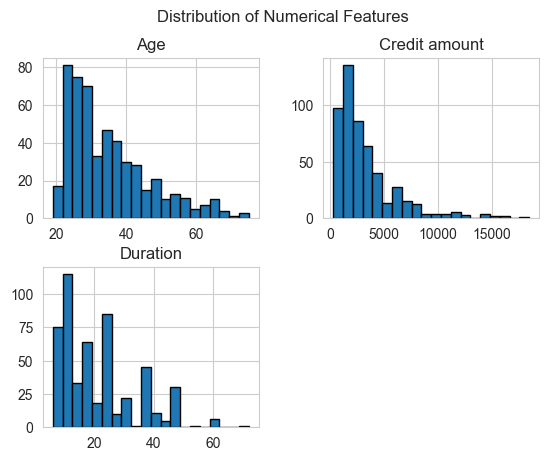

In [73]:
df[['Age', 'Credit amount','Duration']].hist(bins=20, edgecolor = 'black')
plt.suptitle("Distribution of Numerical Features")
plt.show()

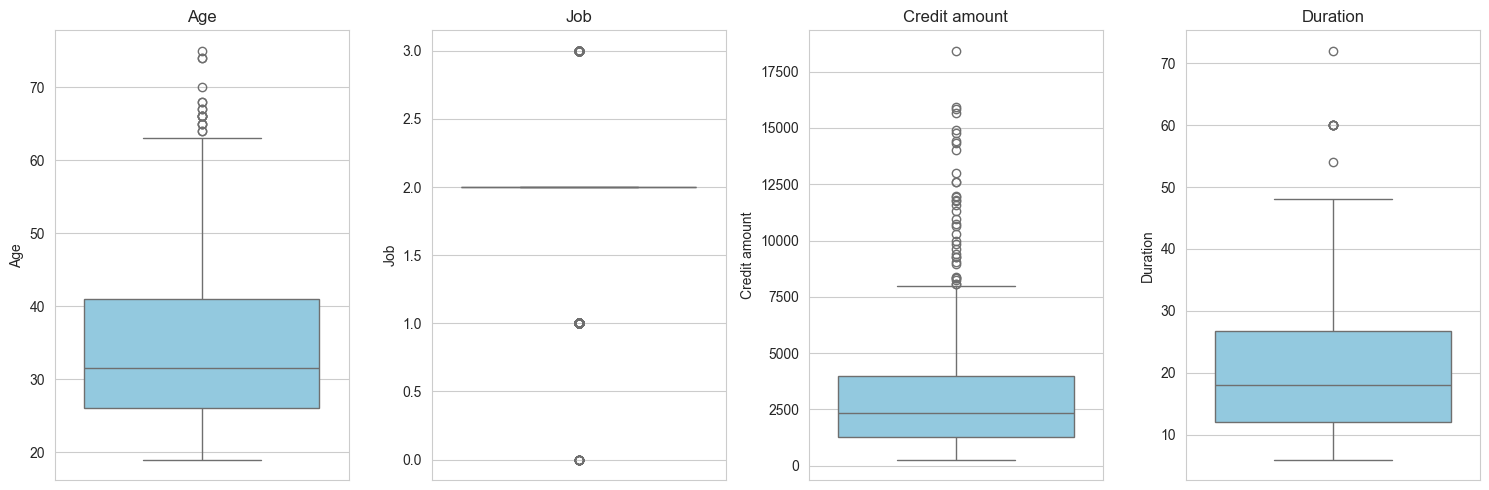

In [74]:
plt.figure(figsize=(15,5))

for i, col in enumerate(num_cols):
    plt.subplot(1, 4, i+1)
    sns.boxplot(y = df[col], color = "skyblue")
    plt.title(col)

plt.tight_layout()
plt.show()

In [75]:
df.query("Duration >= 60")

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
18,63,male,2,own,little,little,6836,60,business,bad
176,24,female,3,own,moderate,moderate,7408,60,car,bad
199,60,female,3,free,moderate,moderate,14782,60,vacation/others,bad
358,24,male,2,own,moderate,moderate,5595,72,radio/TV,bad
378,27,male,3,own,little,moderate,14027,60,car,bad
489,42,male,2,free,little,moderate,6288,60,education,bad
507,36,male,2,rent,little,little,7297,60,business,bad


In [76]:
cat_cols = ['Sex', 'Job', 'Housing', 'Saving accounts', 'Checking account', 'Purpose']

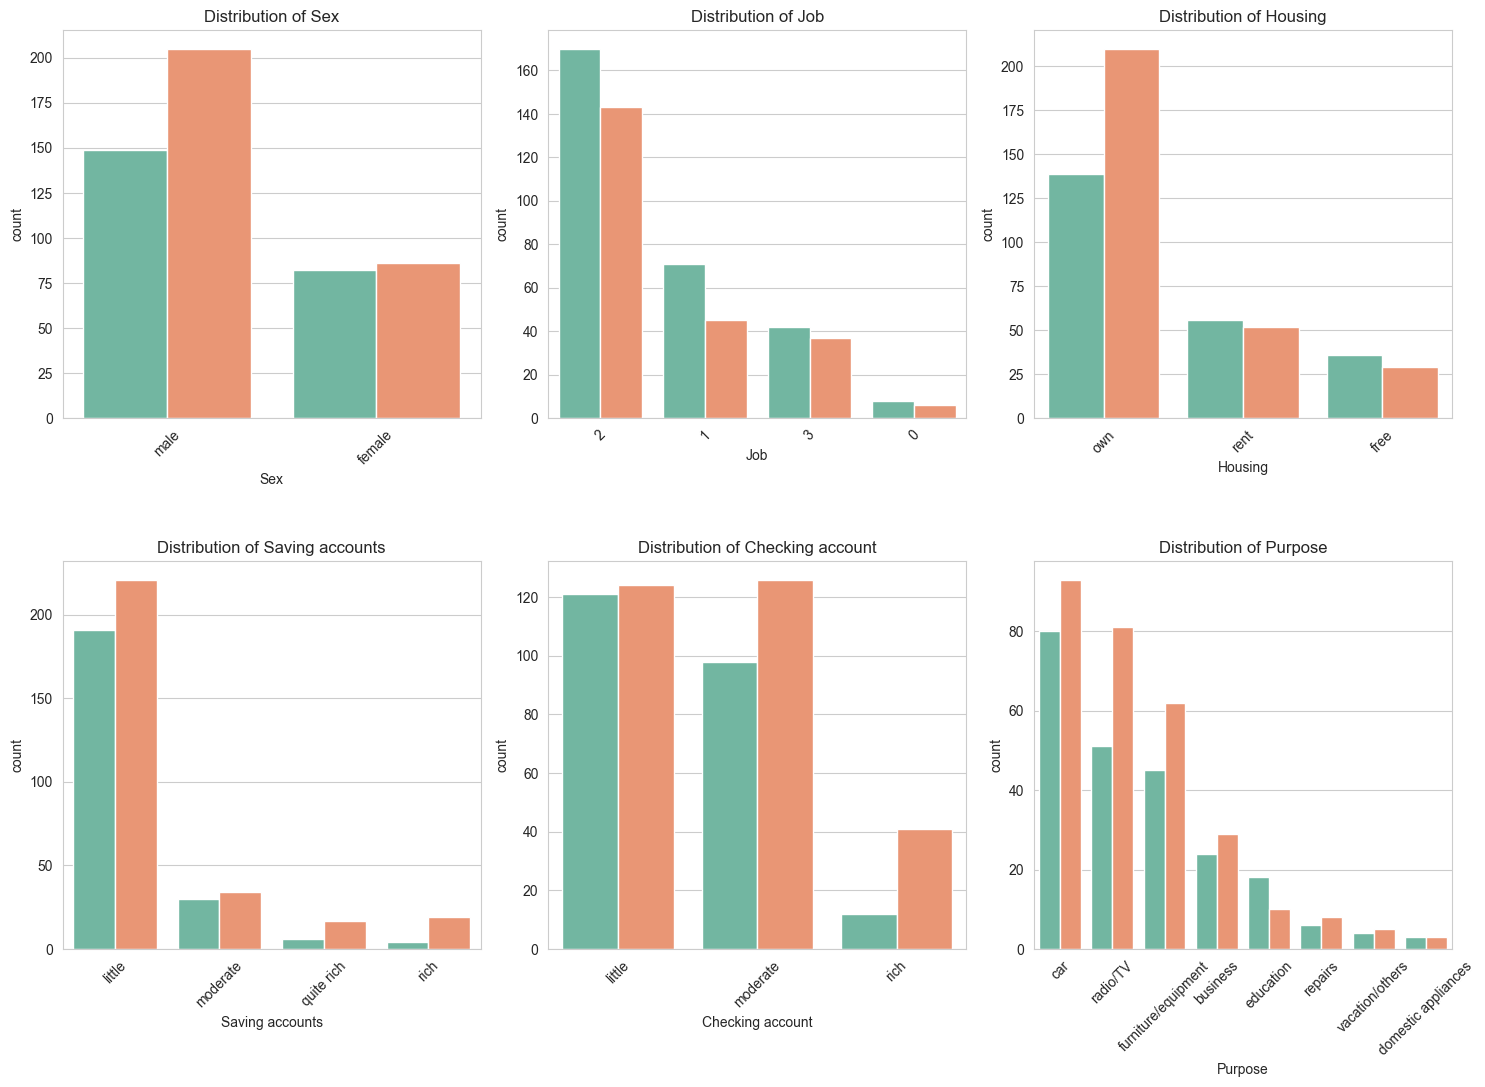

In [77]:
plt.figure(figsize=(15,15))
for i, col in enumerate(cat_cols):
    plt.subplot(3,3,i+1)
    sns.countplot(
    data=df,
    x=col,
    hue="Risk",
    palette="Set2",
    order=df[col].value_counts().index,
    legend=False
)
    plt.title(f"Distribution of {col}")
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [78]:
corr = df[num_cols].corr()

<Axes: >

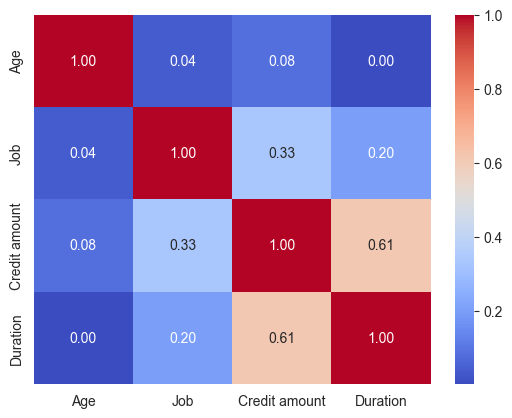

In [79]:
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")

In [80]:
df.groupby("Job")["Credit amount"].mean()

Job
0    1767.857143
1    2250.715517
2    3129.130990
3    5648.784810
Name: Credit amount, dtype: float64

In [81]:
df.groupby("Sex")["Credit amount"].mean()

Sex
female    2937.202381
male      3440.833333
Name: Credit amount, dtype: float64

Text(0.5, 1.0, 'Credit amount vs Age colored by Sex and sized by Duration')

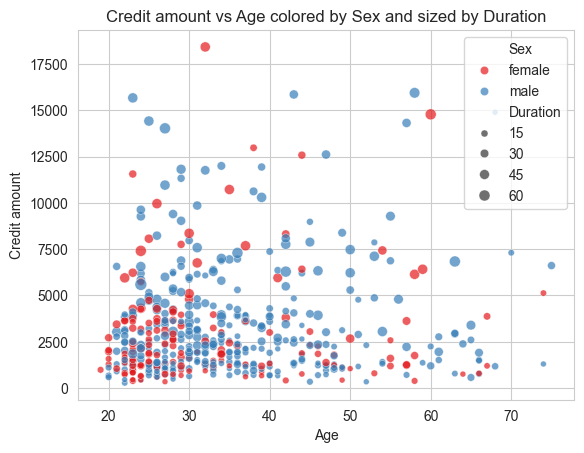

In [82]:
sns.scatterplot(data=df, x="Age", y='Credit amount', hue="Sex", size="Duration", alpha=0.7, palette="Set1")
plt.title("Credit amount vs Age colored by Sex and sized by Duration")

/var/folders/20/g8yf7jjj72n76r9284flgkcw0000gn/T/ipykernel_34947/681165044.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x="Saving accounts", y="Credit amount", palette="Pastel1")


Text(0.5, 1.0, 'Credit amount distribution by saving account')

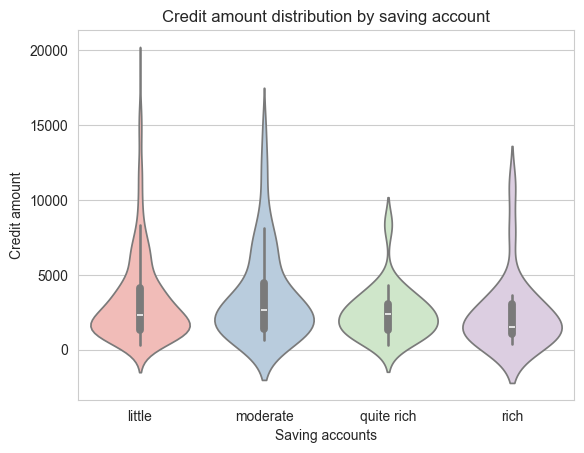

In [83]:
sns.violinplot(data=df, x="Saving accounts", y="Credit amount", palette="Pastel1")
plt.title("Credit amount distribution by saving account")

In [84]:
df["Risk"].value_counts(normalize=True) * 100

Risk
good    55.747126
bad     44.252874
Name: proportion, dtype: float64

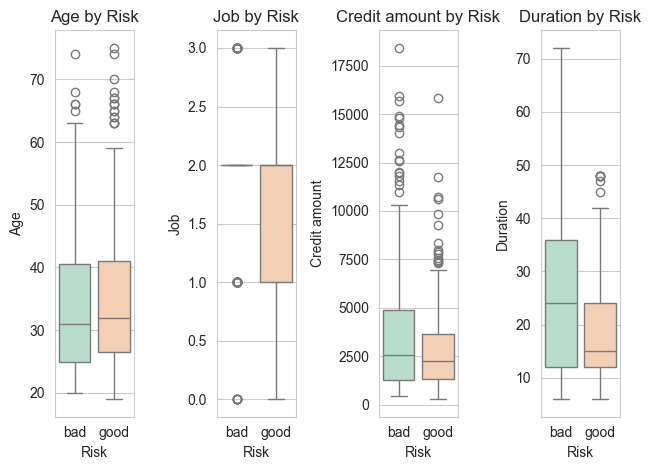

In [85]:
for i, col in enumerate(num_cols):
    plt.subplot(1,4,i+1)
    sns.boxplot(data=df, x="Risk", hue="Risk", y=col, palette="Pastel2")
    plt.title(f"{col} by Risk")

plt.tight_layout()
plt.show()

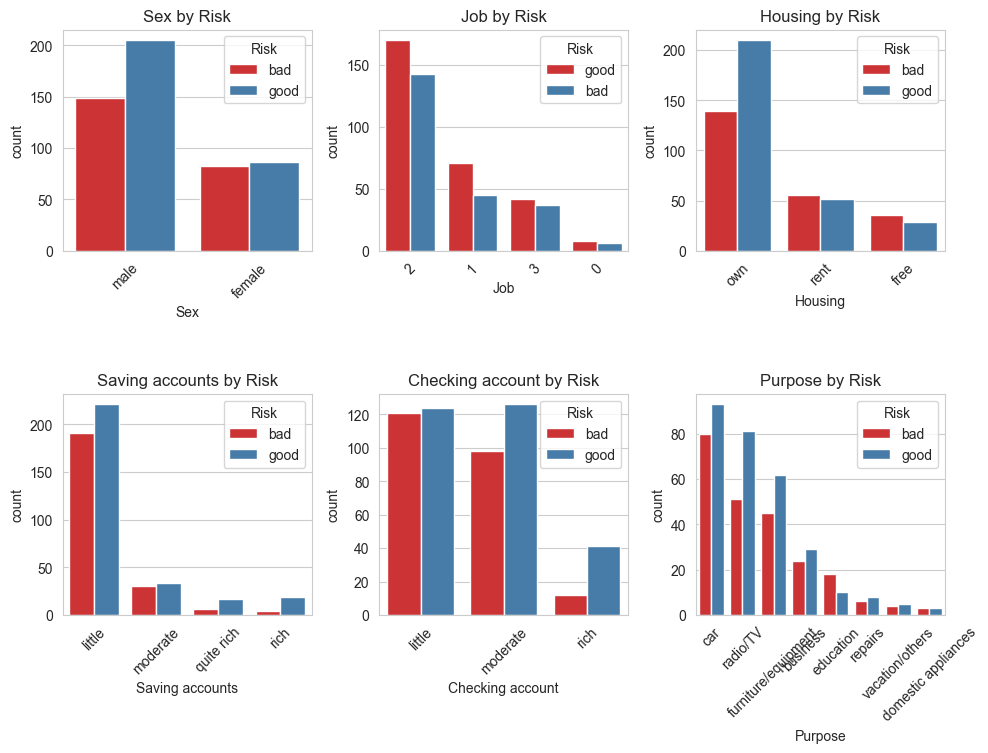

In [86]:

plt.figure(figsize=(10,10))
for i, col in enumerate(cat_cols):
    plt.subplot(3,3,i+1)
    sns.countplot(data=df, x=col, hue="Risk", palette="Set1", order=df[col].value_counts().index)
    plt.title(f"{col} by Risk")
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [87]:
features = num_cols + cat_cols

In [88]:
target = "Risk"

In [89]:
df_model = df[features+[target]].copy()

In [90]:
df_model.head()

,Age,Job,Credit amount,Duration,Sex,Job,Housing,Saving accounts,Checking account,Purpose,Risk
0,22,2,5951,48,female,2,own,little,moderate,radio/TV,bad
1,45,2,7882,42,male,2,free,little,little,furniture/equipment,good
2,53,2,4870,24,male,2,free,little,little,car,bad
3,35,3,6948,36,male,3,rent,little,moderate,car,good
4,28,3,5234,30,male,3,own,little,moderate,car,bad


In [91]:
from sklearn.preprocessing import LabelEncoder
import joblib

In [92]:
cat_cols = df_model.select_dtypes(include="object").columns.drop("Risk")

In [93]:
cat_cols

Index(['Sex', 'Housing', 'Saving accounts', 'Checking account', 'Purpose'], dtype='object')

In [94]:
le_dict = {}

for col in cat_cols:
    le = LabelEncoder()
    df_model[col] = le.fit_transform(df_model[col])
    le_dict[col] = le
    joblib.dump(le, f"{col}_encoder.pkl")

In [95]:
le_target = LabelEncoder()

In [96]:
df_model[target] = le_target.fit_transform(df_model[target])

In [97]:
df_model[target].value_counts()

Risk
1    291
0    231
Name: count, dtype: int64

In [98]:
joblib.dump(le_target, "target_encoder.pkl")

['target_encoder.pkl']

In [99]:
df_model.head()

,Age,Job,Credit amount,Duration,Sex,Job,Housing,Saving accounts,Checking account,Purpose,Risk
0,22,2,5951,48,0,2,1,0,1,5,0
1,45,2,7882,42,1,2,0,0,0,4,1
2,53,2,4870,24,1,2,0,0,0,1,0
3,35,3,6948,36,1,3,2,0,1,1,1
4,28,3,5234,30,1,3,1,0,1,1,0


In [100]:
from sklearn.model_selection import train_test_split

In [101]:
X = df_model.drop(target, axis=1)
y = df_model[target]

In [102]:
X.shape

(522, 10)

In [103]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=1)

In [104]:
X_train.shape

(417, 10)

In [113]:
!pip install scikit-learn xgboost lightgbm catboost

  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 5.6 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 5.6 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 28.8/28.8 MB 6.0 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 309.1/309.1 kB 5.6 MB/s eta 0:00:00a 0:00:01
Using cached threadpoolctl-3.6.0-py3-none-any.whl (18 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.3/47.3 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 6.8 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 444.9/444.9 kB 7.1 MB/s eta 0:00:00a 0:00:01


In [115]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import GridSearchCV

In [116]:
def train_model(model, param_grid, X_train, y_train, X_test, y_test):
    grid = GridSearchCV(model, param_grid, cv = 5, scoring="accuracy", n_jobs=-1)
    grid.fit(X_train, y_train)
    best_model = grid.best_estimator_
    y_pred = best_model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    return best_model, acc, grid.best_params_

In [117]:
dt = DecisionTreeClassifier(random_state=1, class_weight="balanced")
dt_param_grid = {
    "max_depth": [3,5,7,10,None],
    "min_samples_split":[2,5,10],
    "min_samples_leaf":[1,2,4]
}

In [119]:
best_dt, acc_dt, params_dt = train_model(dt, dt_param_grid, X_train, y_train, X_test, y_test)

In [120]:
print("Decision Tree Accuracy: ", acc_dt)

Decision Tree Accuracy:  0.5904761904761905


In [121]:
print("Best Params", params_dt)

Best Params {'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 2}


In [124]:
rf = RandomForestClassifier(random_state=1, class_weight="balanced", n_jobs=-1)
rf_param_grid = {
    "n_estimators" : [100,200],
    "max_depth": [5, 7, 10, None],
    "min_samples_split": [2,5,10],
    "min_samples_leaf": [1,2,4]
}

In [125]:
best_rf, acc_rf, params_rf = train_model(rf, rf_param_grid, X_train, y_train, X_test, y_test)

In [126]:
print("Random Forest Accuracy ", acc_rf)

Random Forest Accuracy  0.6285714285714286


In [127]:
print("Best Params ",params_rf)

Best Params  {'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 10, 'n_estimators': 100}


In [129]:
et = ExtraTreesClassifier(random_state=1, class_weight="balanced", n_jobs=-1)

In [130]:
et_param_grid = {
    "n_estimators" : [100,200],
    "max_depth": [5, 7, 10, None],
    "min_samples_split": [2,5,10],
    "min_samples_leaf": [1,2,4]
}

In [131]:
best_et, acc_et, params_et = train_model(et, et_param_grid, X_train, y_train, X_test, y_test)

In [132]:
print("Extra Trees Accuracy ", acc_et)

Extra Trees Accuracy  0.6761904761904762


In [133]:
print("Best PArams", params_et)

Best PArams {'max_depth': None, 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 100}


In [134]:
joblib.dump(best_et, "extra_trees.pkl")

['extra_trees.pkl']

In [135]:
df["Purpose"].unique()

array(['radio/TV', 'furniture/equipment', 'car', 'business',
       'domestic appliances', 'repairs', 'vacation/others', 'education'],
      dtype=object)

In [137]:
df_model.columns

Index(['Age', 'Job', 'Credit amount', 'Duration', 'Sex', 'Job', 'Housing',
       'Saving accounts', 'Checking account', 'Purpose', 'Risk'],
      dtype='object')